Kích thước ảnh: (1414, 2119, 3)


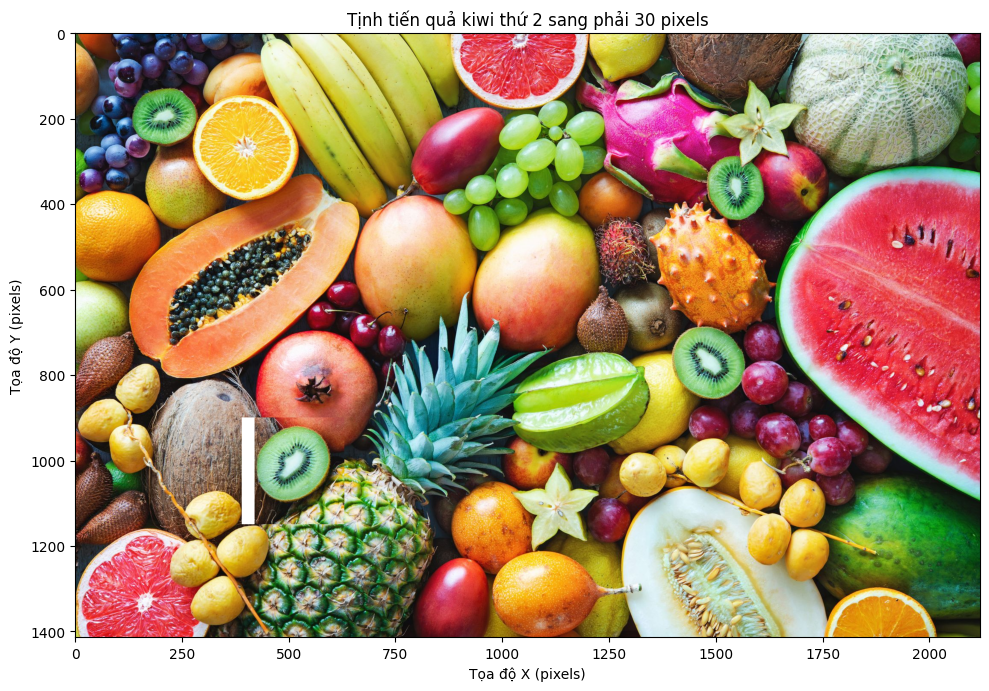

In [46]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt

# Đọc ảnh gốc
image = iio.imread('exercise/colorful-ripe-tropical-fruits.jpg')
print("Kích thước ảnh:", image.shape)

# ======== 1. Cắt quả kiwi thứ 2 theo tọa độ ========
x1, y1 = 390, 900
x2, y2 = 600, 1150
kiwi2 = image[y1:y2, x1:x2]

# ======== 2. Tạo bản sao ảnh để xử lý ========
output = image.copy()

# Xóa kiwi gốc (tô trắng)
output[y1:y2, x1:x2] = [255, 255, 255]

# ======== 3. Tịnh tiến kiwi sang phải 30px ========
offset = 30
new_x1 = x1 + offset
new_x2 = new_x1 + kiwi2.shape[1]

# Kiểm tra giới hạn ảnh
if new_x2 <= image.shape[1]:
    output[y1:y2, new_x1:new_x2] = kiwi2
else:
    print("Vị trí mới vượt giới hạn ảnh!")

# ======== 4. Hiển thị ảnh có trục tọa độ ========
plt.figure(figsize=(10, 8))
plt.imshow(output)
plt.title("Tịnh tiến quả kiwi thứ 2 sang phải 30 pixels")
plt.xlabel("Tọa độ X (pixels)")
plt.ylabel("Tọa độ Y (pixels)")
plt.grid(False)
plt.tight_layout()
plt.show()


In [48]:
!pip install scikit-image

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
    --------------------------------------- 0.3/12.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.8 MB 1.4 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/12.8 MB 1.8 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/12.8 MB 1.4 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/12.8 MB 1.3 MB/s eta 0:00:10
   ---- ----------------------------------- 1.6/12.8 MB 1.2 MB/s eta 0:00:10
   ---- ----------------------------------- 1.6/12.8 MB 1.2 MB/s eta 0:00:10
   ----- ---------------------------------- 1.8/12.8 MB 1.1 MB/s eta 0:00:10
   ------ --------------------------------- 2.1/12.8 MB 1.1 MB/s eta 0:00:10
   ------- -------------------------------- 2.4/12.8 MB 1.1 MB/s eta 0:00:10
   ------- -------------------------------- 2.4/12.8 MB 1.1 MB/s eta 0:00:10
   -------- ------------------------------- 2.6/12.8 MB 1.1 MB/s eta 0:00:10
   --------- 


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


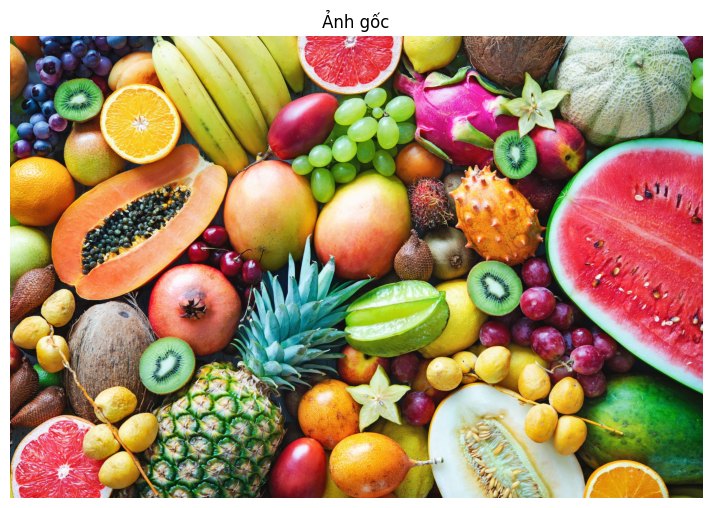

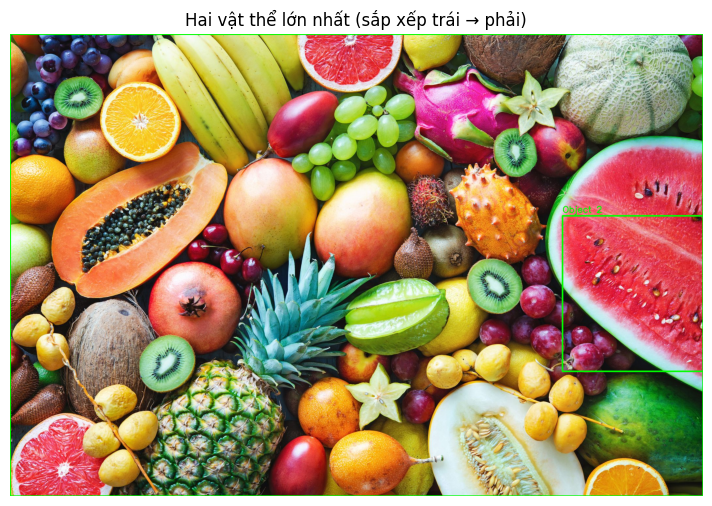

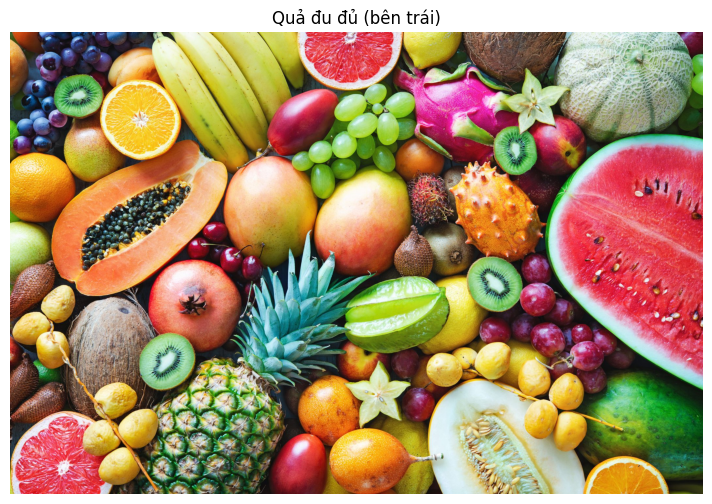

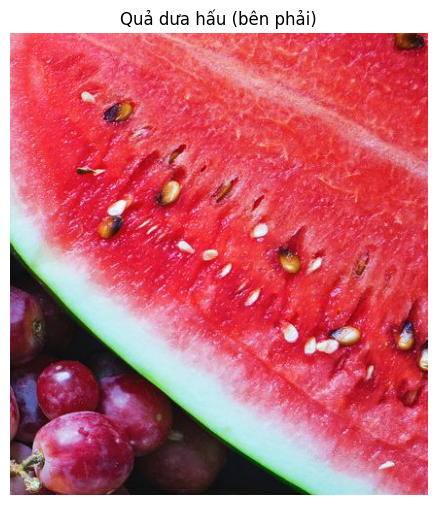

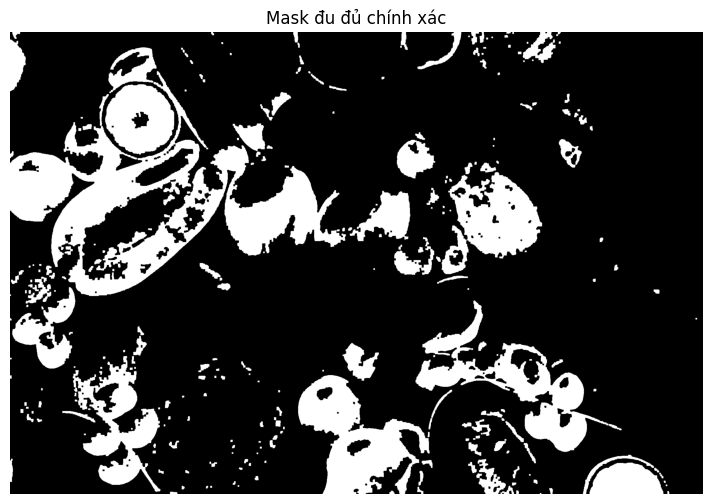

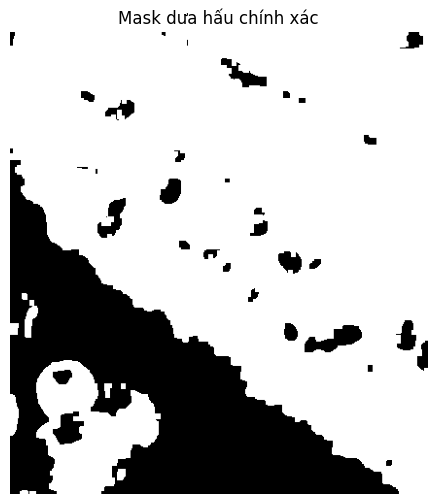

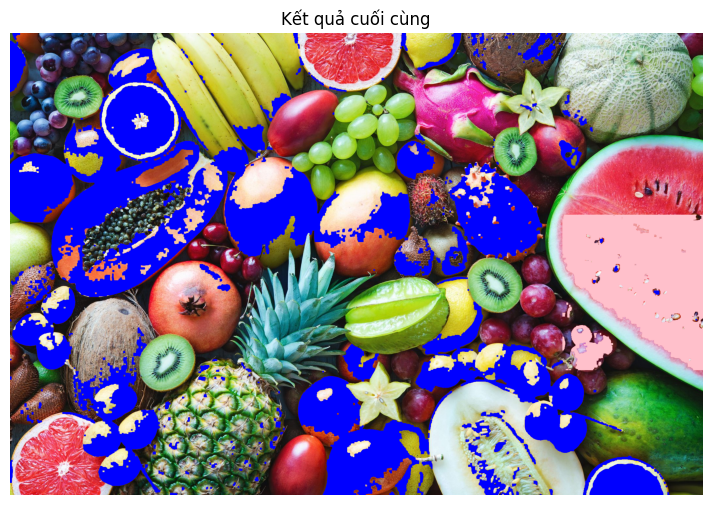

✅ Đã lưu ảnh kết quả thành 'precise_result.jpg'


In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def display(img, title='', cmap=None):
    plt.figure(figsize=(10, 6))
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

# === Bước 1: Đọc ảnh ===
image = cv2.imread('exercise/colorful-ripe-tropical-fruits.jpg')
if image is None:
    raise FileNotFoundError("❌ Không tìm thấy ảnh! Kiểm tra lại đường dẫn.")

display(image, 'Ảnh gốc')

# === Bước 2: Phát hiện các vật thể lớn ===
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

height, width = image.shape[:2]
min_area = 0.02 * height * width  # Chỉ lấy vật thể lớn hơn 5% diện tích ảnh

large_objects = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

if len(large_objects) < 2:
    raise ValueError("❌ Không tìm thấy đủ 2 vật thể lớn trong ảnh.")

# Sắp xếp và chọn 2 vật thể lớn nhất theo diện tích
large_objects = sorted(large_objects, key=cv2.contourArea, reverse=True)[:2]
large_objects = sorted(large_objects, key=lambda cnt: cv2.boundingRect(cnt)[0])  # trái → phải

# Hiển thị vật thể
large_objects_img = image.copy()
for i, cnt in enumerate(large_objects):
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(large_objects_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cv2.putText(large_objects_img, f"Object {i + 1}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

display(large_objects_img, 'Hai vật thể lớn nhất (sắp xếp trái → phải)')

# === Bước 3: Cắt ROI từng quả ===
x1, y1, w1, h1 = cv2.boundingRect(large_objects[0])  # trái
papaya_roi = image[y1:y1 + h1, x1:x1 + w1]
display(papaya_roi, 'Quả đu đủ (bên trái)')

x2, y2, w2, h2 = cv2.boundingRect(large_objects[1])  # phải
watermelon_roi = image[y2:y2 + h2, x2:x2 + w2]
display(watermelon_roi, 'Quả dưa hấu (bên phải)')

# === Bước 4: Tạo mask chính xác bằng HSV ===
def create_precise_mask(roi, lower_hsv, upper_hsv):
    hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_roi, lower_hsv, upper_hsv)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

# Đu đủ: màu cam
lower_papaya = np.array([10, 100, 100])
upper_papaya = np.array([25, 255, 255])
papaya_mask = create_precise_mask(papaya_roi, lower_papaya, upper_papaya)
display(papaya_mask, 'Mask đu đủ chính xác', cmap='gray')

# Dưa hấu: màu đỏ (2 vùng đỏ HSV)
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])
mask1 = create_precise_mask(watermelon_roi, lower_red1, upper_red1)
mask2 = create_precise_mask(watermelon_roi, lower_red2, upper_red2)
watermelon_mask = cv2.bitwise_or(mask1, mask2)
display(watermelon_mask, 'Mask dưa hấu chính xác', cmap='gray')

# === Bước 5: Đổi màu trên ảnh gốc ===
result = image.copy()

# Đu đủ sang xanh dương
result[y1:y1 + h1, x1:x1 + w1][papaya_mask > 0] = [255, 0, 0]  # BGR

# Dưa hấu sang hồng
result[y2:y2 + h2, x2:x2 + w2][watermelon_mask > 0] = [203, 192, 255]

display(result, 'Kết quả cuối cùng')

# === Bước 6: Lưu kết quả ===
cv2.imwrite('precise_result.jpg', result)
print("✅ Đã lưu ảnh kết quả thành 'precise_result.jpg'")
